# BÀI TẬP: MEDICAL INSURANCE COST
**Nguồn:** kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset



## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')


csv_path = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [62]:
# TODO
print("So dong: ",df.shape[0])
print("So cot: ",df.shape[1])
df.info()

So dong:  1338
So cot:  7
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## A.2. Missing values & Duplicate data

In [91]:
print(df.columns.tolist())

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [93]:
missing = df.isnull().sum()
print("Missing values: ")
if(missing.sum()>0):
    print(missing[missing>0])
else:
    print("Khong co cot nao thieu du lieu")
print("Duplicate rows (toàn bộ):", df.duplicated().sum())
print("Duplicate theo khóa :", df.duplicated(subset=['children', 'region']).sum())

Missing values: 
Khong co cot nao thieu du lieu
Duplicate rows (toàn bộ): 1
Duplicate theo khóa : 1314


## A.3. Invalid values

In [125]:
print("Age <= 0: ", (df['age']<=0).sum())
print("Gender khac male or femal:", ((df['sex']!='male') | (df['sex']!='female')).sum())

Age <= 0:  0
Gender khac male or femal: 1338


## A.4. Create a new column
Tạo cột `bmi_group`: Normal (<25), Overweight (25-30), Obese (>=30).

In [135]:
def classify_bmi(bmi):
    if bmi < 25:
        return 'Normal'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_group']=df['bmi'].apply(classify_bmi)

print(df[['bmi', 'bmi_group']].head())

      bmi   bmi_group
0  27.900  Overweight
1  33.770       Obese
2  33.000       Obese
3  22.705      Normal
4  28.880  Overweight


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [161]:
# TODO
for col in ['age','bmi','charges']:
    mean_,median_,mode_=df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_:.2f}, Median={median_:.2f}, Mode={mode_:.2f}")
print()
print("Mode region: ",df['region'].mode()[0])


age: Mean=39.21, Median=39.00, Mode=18.00
bmi: Mean=30.66, Median=30.40, Mode=32.30
charges: Mean=13270.42, Median=9382.03, Mode=1639.56

Mode region:  southeast


## Group 2 — Dispersion

In [170]:
for col in ['age','charges']:
    s=df[col]
    range_ = s.max()-s.min()
    std_=s.std()
    q1,q3 = s.quantile([0.25,0.75]); iqr=q3-q1
    cv=std_/s.mean()
    print(f"---{col}---")
    print(f"Range={range_:.2f}, Std={std_:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")

---age---
Range=46.00, Std=14.05, IQR=24.00, CV=0.36
---charges---
Range=62648.55, Std=12110.01, IQR=11899.63, CV=0.91


## Group 3 — Location and Shape

---bmi---
P25=26.30, P50=30.40, P75=34.69
Skewness=0.28, Kurtosis=-0.06
---charges---
P25=4740.29, P50=9382.03, P75=16639.91
Skewness=1.51, Kurtosis=1.60


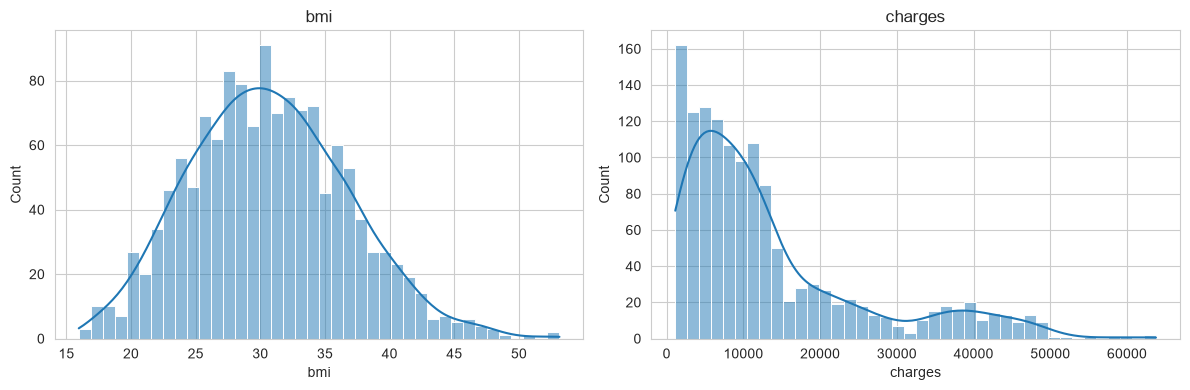

In [ ]:
for col in ['bmi','charges']:
    s=df[col]
    skew_,kurt_=stats.skew(s), stats.kurtosis(s)
    print(f"---{col}---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")

fig, axes =plt.subplots(1,2,figsize=(12,4))
sns.histplot(df['bmi'],bins=40,kde=True,ax=axes[0]); axes[0].set_title('bmi')
sns.histplot(df['charges'],bins=40,kde=True,ax=axes[1]); axes[1].set_title('charges')
plt.tight_layout(); plt.show()

print("Nhan xet: bmi lech phai va co kurtosis thap hon charges")


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Người hút thuốc trả chi phí cao hơn bao nhiêu lần so với người không hút, và có đồng đều giữa các vùng không?

smoker          no       yes  ratio
region                             
northeast  9165.53  29673.54   3.24
northwest  8556.46  30192.00   3.53
southeast  8032.22  34845.00   4.34
southwest  8019.28  32269.06   4.02


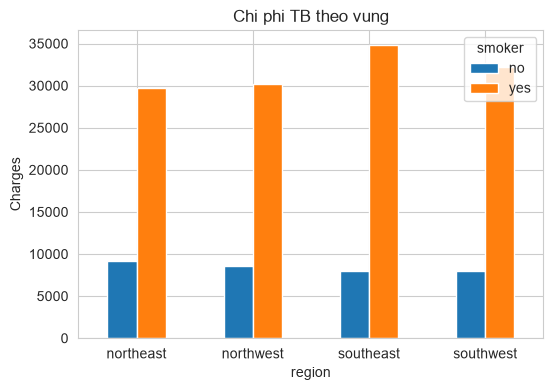

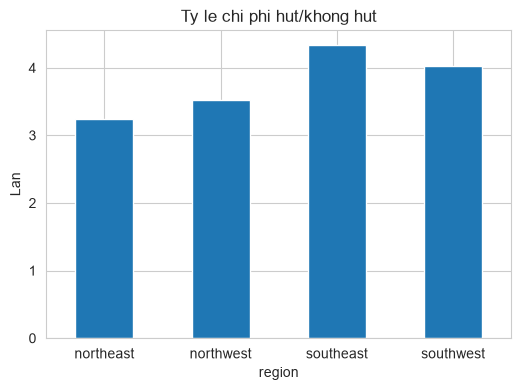

In [185]:
# bang so lieu
comp=df.groupby(['region','smoker'])['charges'].mean().unstack()
comp['ratio']=comp['yes']/comp['no']
print(comp.round(2))

#so sanh chi phi theo vung
comp[['no', 'yes']].plot(kind='bar', figsize=(6,4), title='Chi phi TB theo vung')
plt.ylabel('Charges'); plt.xticks(rotation=0); plt.show()

#so sanh ty le chenh lech
comp['ratio'].plot(kind='bar', figsize=(6,4), title='Ty le chi phi hut/khong hut')
plt.ylabel('Lan'); plt.xticks(rotation=0); plt.show()

## Câu hỏi 2: BMI có tương quan với chi phí mạnh hơn ở nhóm hút thuốc hay không hút thuốc?

Smoker = yes: Pearson = 0.806, Spearman = 0.834
Smoker = no: Pearson = 0.084, Spearman = 0.105


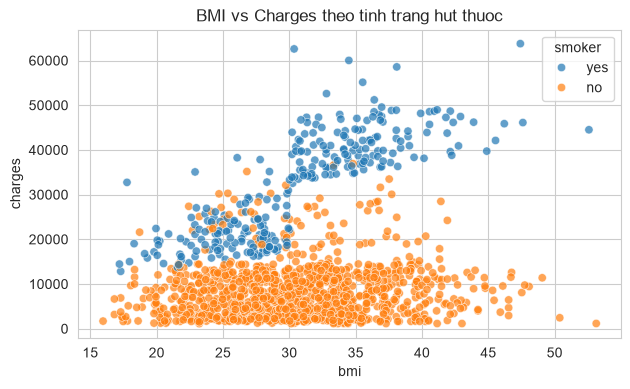

In [194]:
# tinh he so tuong quan tung nhom
for s in ['yes','no']:
    subset=df[df['smoker']==s]
    corr_p=subset['bmi'].corr(subset['charges'])
    corr_s=subset['bmi'].corr(subset['charges'], method='spearman')
    print(f"Smoker = {s}: Pearson = {corr_p:.3f}, Spearman = {corr_s:.3f}")

#ve bieu do so sanh
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.7, ax=ax)
ax.set_title('BMI vs Charges theo tinh trang hut thuoc')
plt.show()

## Câu hỏi 3: Vùng nào có chi phí bảo hiểm trung bình cao nhất?

In [201]:
# 
charges_region=df.groupby('region')['charges'].mean().sort_values(ascending=False)
high_charges_region=charges_region.index[0]
max_charges=charges_region.iloc[0]
print("Vung co chi phi bao hiem trung binh cao nhat: ",high_charges_region,max_charges)


Vung co chi phi bao hiem trung binh cao nhat:  southeast 14735.41143760989


## Câu hỏi 4: Số lượng con cái có làm tăng chi phí bảo hiểm không?

In [208]:
# TODO
corr_p = df['children'].corr(df['charges'])
corr_s = df['children'].corr(df['charges'], method='spearman')
print(f"Pearson: {corr_p:.3f} | Spearman: {corr_s:.3f}\n")

print(df.groupby('children')['charges'].agg(['count', 'mean', 'median']).round(2))



Pearson: 0.068 | Spearman: 0.133

          count      mean    median
children                           
0           574  12365.98   9856.95
1           324  12731.17   8483.87
2           240  15073.56   9264.98
3           157  15355.32  10600.55
4            25  13850.66  11033.66
5            18   8786.04   8589.57


## Câu hỏi 5: Tuổi có tương quan với chi phí bảo hiểm không?

In [211]:
# Tinh he so tuong quan giua tuoi va chi phi
corr_p = df['age'].corr(df['charges'])
corr_s = df['age'].corr(df['charges'], method='spearman')
print(f"Pearson: {corr_p:.3f} | Spearman: {corr_s:.3f}")

# Chi phi trung binh theo tung nhom tuoi (chia theo khoang 10 nam)
df['age_group'] = pd.cut(df['age'], bins=[17, 30, 40, 50, 65], labels=['18-30', '31-40', '41-50', '51-64'])
print(df.groupby('age_group', observed=False)['charges'].agg(['count', 'mean', 'median']).round(2))

print("Tuoi tac co tuong quan voi chi phi bao hiem")

Pearson: 0.299 | Spearman: 0.534
           count      mean    median
age_group                           
18-30        444   9397.55   3392.67
31-40        257  11639.31   6334.34
41-50        281  14782.04   8964.06
51-64        356  18084.99  12736.08
Tuoi tac co tuong quan voi chi phi bao hiem


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

*Người hút thuốc trả chi phí cao hơn người không hút. BMI có tương quan giữa nhóm không hút và nhóm hút. Vùng southeast có chi phí bảo hiểm trung bình cao nhất. Số lượng con cái không làm tăng chi phí bảo hiểm. Tuổi có tương quan với chi phí bảo hiểm.*